<a href="https://colab.research.google.com/github/Bakixo/AIRLINE-PASSENGER-FORECASTING/blob/MachineSoftware/2_denemeDCGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
from google.colab import files
files.upload()

! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d shadyeldakrory/shadyfinal3
!unzip shadyfinal3.zip


Saving kaggle.json to kaggle (2).json
mkdir: cannot create directory ‘/root/.kaggle’: File exists
Dataset URL: https://www.kaggle.com/datasets/shadyeldakrory/shadyfinal3
License(s): unknown
shadyfinal3.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  shadyfinal3.zip
replace test/Glioma/1259.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [43]:
# %matplotlib inline
import os, random, csv, math, glob
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.datasets as dset
import torchvision.transforms as T
import torchvision.utils as vutils
from torchvision.utils import save_image
from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler

SEED = 999
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda:0


In [44]:
# Klasör yapın: train/validation/test altında: Glioma, Meningioma, Pituitary, no_tumor
DATA_ROOT_TRAIN = "/content/train"  # sadece OKUMA

# Bu run'da eğitilecek sınıf (case-sensitive)
CLASS_NAME  = "Glioma"  # "Meningioma" | "Pituitary" | "no_tumor"

# DCGAN & Data
IMAGE_SIZE  = 128
BATCH_SIZE  = 32          # 128x128 için VRAM güvenli; GPU’n güçlüyse 48/64 deneyebilirsin
WORKERS     = 4
nc, nz = 1, 128           # GRAYSCALE + latent boyutu biraz büyüttük
ngf, ndf = 64, 64
EPOCHS = 150              # istersen 200’e çıkaracağız (fine-tune)

# Öğrenme oranları (dengeli)
LR_D, LR_G = 2e-4, 2e-4
BETA1 = 0.5

# Etiket yumuşatma + flip
REAL_LABEL = 0.9
FAKE_LABEL = 0.1
FLIP_P = 0.02

# Instance noise planı (başta 0.10, sonlara doğru 0)
NOISE_SIGMA0 = 0.10

# Çıktılar (sadece YAZMA; veri setine yazmıyoruz)
RUN_NAME   = f"dcgan128_{CLASS_NAME}_ep{EPOCHS}"
SAVE_ROOT  = f"/content/outputs/{RUN_NAME}"
FAKE_DIR   = f"{SAVE_ROOT}/fake"
CKPT_DIR   = f"{SAVE_ROOT}/checkpoints"
LOG_DIR    = f"{SAVE_ROOT}/logs"
os.makedirs(FAKE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,  exist_ok=True)

print("Train read-only dir:", os.path.join(DATA_ROOT_TRAIN, CLASS_NAME))
print("Write-only outputs :", SAVE_ROOT)


Train read-only dir: /content/train/Glioma
Write-only outputs : /content/outputs/dcgan128_Glioma_ep150


Train/Glioma örnek sayısı: 4687


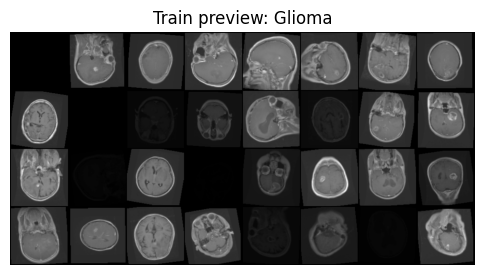

In [45]:
from torchvision.transforms import InterpolationMode as IM

"""train_ds = dset.ImageFolder(
    root=DATA_ROOT_TRAIN,
    transform=T.Compose([
        T.Grayscale(num_output_channels=1),
        T.Resize(IMAGE_SIZE, interpolation=IM.BILINEAR),
        T.CenterCrop(IMAGE_SIZE),

        # hafif ama faydalı augmentasyonlar
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(10, fill=0, interpolation=IM.BILINEAR),
        T.RandomAffine(degrees=0, translate=(0.02, 0.02),
                       scale=(0.95, 1.05), fill=0, interpolation=IM.BILINEAR),

        T.ToTensor(),
        T.Normalize((0.5,), (0.5,)),
    ])
)"""

train_ds = dset.ImageFolder(
    root=DATA_ROOT_TRAIN,
    transform=T.Compose([
        T.Grayscale(num_output_channels=1),
        T.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=IM.BILINEAR),
        T.CenterCrop((IMAGE_SIZE, IMAGE_SIZE)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(10, fill=0, interpolation=IM.BILINEAR),
        T.RandomAffine(degrees=0, translate=(0.02, 0.02),
                       scale=(0.95, 1.05), fill=0, interpolation=IM.BILINEAR),
        T.ToTensor(),
        T.Normalize((0.5,), (0.5,)),
    ])
)



assert CLASS_NAME in train_ds.class_to_idx, f"{CLASS_NAME} klasörü train/ içinde bulunamadı!"
target_idx = train_ds.class_to_idx[CLASS_NAME]
indices = [i for i,(_,y) in enumerate(train_ds.samples) if y == target_idx]
subset = data.Subset(train_ds, indices)

loader = data.DataLoader(
    subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=WORKERS,
    drop_last=True, pin_memory=True, persistent_workers=True if WORKERS>0 else False
)

print(f"Train/{CLASS_NAME} örnek sayısı:", len(indices))
# Hızlı görsel kontrol
real_batch = next(iter(loader))
grid = vutils.make_grid(real_batch[0][:64], padding=2, normalize=True)
plt.figure(figsize=(6,6)); plt.axis("off"); plt.title(f"Train preview: {CLASS_NAME}")
plt.imshow(np.transpose(grid.cpu(), (1,2,0))); plt.show()


In [46]:
def weights_init(m):
    cname = m.__class__.__name__
    if 'Conv' in cname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in cname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        # nz x 1 x 1 → (ngf*8) x 4 x 4
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),

            # 4 → 8
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),

            # 8 → 16
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),

            # 16 → 32
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),

            # 32 → 64  (ekstra ara katman: daha fazla detay için yararlı)
            nn.ConvTranspose2d(ngf, ngf//2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf//2), nn.ReLU(True),

            # 64 → 128
            nn.ConvTranspose2d(ngf//2, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )
            # İsteğe bağlı çeşitlilik için hafif dropout:
        self.drop = nn.Dropout2d(p=0.1)

    def forward(self, z):
        x = self.main[0:6](z)   # ilk iki bloktan sonra
        x = self.drop(x)
        x = self.main[6:](x)
        return x

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        ch = ndf
        self.main = nn.Sequential(
            # 128 → 64
            nn.utils.spectral_norm(nn.Conv2d(nc, ch//2, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 → 32
            nn.utils.spectral_norm(nn.Conv2d(ch//2, ch, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 → 16
            nn.utils.spectral_norm(nn.Conv2d(ch, ch*2, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 → 8
            nn.utils.spectral_norm(nn.Conv2d(ch*2, ch*4, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # 8 → 4
            nn.utils.spectral_norm(nn.Conv2d(ch*4, ch*8, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # 4 → 1
            nn.utils.spectral_norm(nn.Conv2d(ch*8, 1, 4, 1, 0, bias=False)),  # logits
        )
    def forward(self, x): return self.main(x).view(-1)

netG = Generator().to(device).apply(weights_init)
netD = Discriminator().to(device).apply(weights_init)

criterion  = nn.BCEWithLogitsLoss()
optimizerD = optim.Adam(netD.parameters(), lr=LR_D, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR_G, betas=(BETA1, 0.999))

fixed_noise = torch.randn(64, nz, 1, 1, device=device)
print(netG); print(netD)


Generator(
  (main): Sequential(
    (0): ConvTranspose2d(128, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): BatchNorm2d(

In [47]:
def add_noise(x, std):
    if std <= 0: return x
    return x + std * torch.randn_like(x)

def maybe_flip_labels(tensor, p, real_value, fake_value):
    if p <= 0: return tensor
    if torch.rand(1).item() < p:
        flipped = torch.full_like(tensor, fake_value if tensor[0].item()==real_value else real_value)
        return flipped
    return tensor


In [48]:
USE_AMP = True
scalerG = GradScaler(enabled=USE_AMP)
scalerD = GradScaler(enabled=USE_AMP)

G_losses, D_losses = [], []
print(">> Training...")

for epoch in range(1, EPOCHS+1):
    sigma = NOISE_SIGMA0 * max(0.0, 1.0 - epoch/(EPOCHS*0.7))  # kademeli azalır
    pbar = tqdm(enumerate(loader, 0), total=len(loader), leave=False, desc=f"Epoch {epoch}/{EPOCHS}")

    for i, (real, _) in pbar:
        real = real.to(device)
        bsz  = real.size(0)

        # ------------ D ------------
        netD.zero_grad(set_to_none=True)
        label_real = torch.full((bsz,), REAL_LABEL, device=device)
        label_real = maybe_flip_labels(label_real, FLIP_P, REAL_LABEL, FAKE_LABEL)

        with autocast(enabled=USE_AMP):
            out_real = netD(add_noise(real, sigma))
            errD_real = criterion(out_real, label_real)

            noise = torch.randn(bsz, nz, 1, 1, device=device)
            fake  = netG(noise)
            label_fake = torch.full((bsz,), FAKE_LABEL, device=device)
            label_fake = maybe_flip_labels(label_fake, FLIP_P, REAL_LABEL, FAKE_LABEL)
            out_fake = netD(add_noise(fake.detach(), sigma))
            errD_fake = criterion(out_fake, label_fake)

            errD = errD_real + errD_fake

        scalerD.scale(errD).backward()
        scalerD.step(optimizerD)
        scalerD.update()

        # ------------ G ------------
        netG.zero_grad(set_to_none=True)
        with autocast(enabled=USE_AMP):
            out_fake2 = netD(fake)  # logits
            label_trick = torch.full((bsz,), REAL_LABEL, device=device)  # G: D(fake)'i gerçek sansın
            errG = criterion(out_fake2, label_trick)

        scalerG.scale(errG).backward()
        scalerG.step(optimizerG)
        scalerG.update()

        G_losses.append(errG.item()); D_losses.append(errD.item())

        if (i % 10) == 0:
            pbar.set_postfix({"Loss_D": f"{errD.item():.4f}",
                              "Loss_G": f"{errG.item():.4f}",
                              "sigma": f"{sigma:.3f}"})

    # --- her 30 epoch ve son epoch: görsel + checkpoint ---
    if (epoch % 30 == 0) or (epoch == EPOCHS):
        with torch.no_grad():
            fake_fixed = netG(fixed_noise).detach().cpu()
        save_image(fake_fixed, f"{FAKE_DIR}/grid_epoch_{epoch:03d}.png",
                   nrow=8, normalize=True, value_range=(-1,1))
        torch.save(netG.state_dict(), f"{CKPT_DIR}/G_epoch_{epoch:03d}.pt")
        torch.save(netD.state_dict(), f"{CKPT_DIR}/D_epoch_{epoch:03d}.pt")

# loss CSVfff
with open(f"{LOG_DIR}/losses.csv","w",newline="") as f:
    w = csv.writer(f); w.writerow(["step","G_loss","D_loss"])
    for k,(g,d) in enumerate(zip(G_losses, D_losses), start=1):
        w.writerow([k,g,d])

print(">> Done. Outputs:", SAVE_ROOT)


>> Training...


/tmp/ipython-input-2822295131.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scalerG = GradScaler(enabled=USE_AMP)
/tmp/ipython-input-2822295131.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scalerD = GradScaler(enabled=USE_AMP)


Epoch 1/150:   0%|          | 0/146 [00:00<?, ?it/s]

/tmp/ipython-input-2822295131.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
/tmp/ipython-input-2822295131.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 2/150:   0%|          | 0/146 [00:00<?, ?it/s]

...

Epoch 147/150:   0%|          | 0/146 [00:00<?, ?it/s]

Epoch 148/150:   0%|          | 0/146 [00:00<?, ?it/s]

Epoch 149/150:   0%|          | 0/146 [00:00<?, ?it/s]

Epoch 150/150:   0%|          | 0/146 [00:00<?, ?it/s]

>> Done. Outputs: /content/outputs/dcgan128_Glioma_ep150


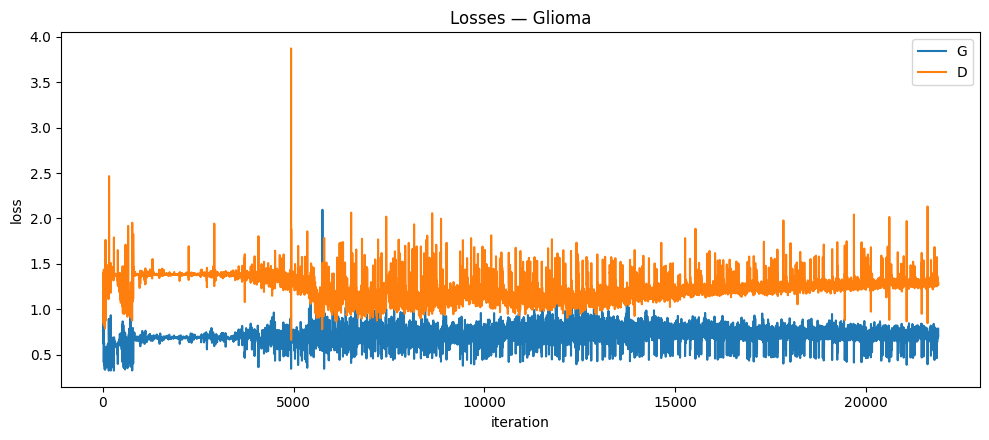

In [49]:
import pandas as pd
df = pd.read_csv(f"{LOG_DIR}/losses.csv")
plt.figure(figsize=(10,4.5))
plt.plot(df["step"], df["G_loss"], label="G")
plt.plot(df["step"], df["D_loss"], label="D")
plt.xlabel("iteration"); plt.ylabel("loss"); plt.title(f"Losses — {CLASS_NAME}")
plt.legend(); plt.tight_layout()
plt.savefig(f"{LOG_DIR}/loss_plot.png", dpi=150)
plt.show()


In [50]:
N_SAMPLES  = 2000
SAMPLES_DIR = f"{FAKE_DIR}/samples"
os.makedirs(SAMPLES_DIR, exist_ok=True)

netG.eval()
with torch.no_grad():
    steps = math.ceil(N_SAMPLES / 64)
    counter = 0
    for _ in range(steps):
        z = torch.randn(64, nz, 1, 1, device=device)
        fake = netG(z).detach().cpu()
        for img in fake:
            counter += 1
            if counter > N_SAMPLES: break
            save_image(img, f"{SAMPLES_DIR}/{counter:06d}.png",
                       normalize=True, value_range=(-1,1))
print("Generated:", len(os.listdir(SAMPLES_DIR)), "images ->", SAMPLES_DIR)
netG.train()


Generated: 3000 images -> /content/outputs/dcgan128_Glioma_ep150/fake/samples


Generator(
  (main): Sequential(
    (0): ConvTranspose2d(128, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): BatchNorm2d(

In [51]:
!pip -q install clean-fid
REAL_DIR = os.path.join(DATA_ROOT_TRAIN, CLASS_NAME)
FAKE_SAMPLES_DIR = f"{FAKE_DIR}/samples"

print("REAL_DIR:", REAL_DIR)
print("FAKE_DIR:", FAKE_SAMPLES_DIR)
!python -m cleanfid.compute --dataset custom --path "$REAL_DIR" --path2 "$FAKE_SAMPLES_DIR" --verbose


REAL_DIR: /content/train/Glioma
FAKE_DIR: /content/outputs/dcgan128_Glioma_ep150/fake/samples
/usr/bin/python3: No module named cleanfid.compute


In [52]:
!python -m cleanfid.compute --dataset custom --path "/content/train/Glioma" --path2 "/content/outputs/dcgan_Glioma_ep150/fake/samples" --verbose


/usr/bin/python3: No module named cleanfid.compute


In [53]:
!pip -q install clean-fid torch-fidelity


In [54]:
import os, glob, math
from torchvision.utils import save_image

# 1️⃣ Doğru dizin (run_name neyse)
SAMPLES_DIR = "/content/outputs/dcgan128_Glioma_ep150/fake/samples"  # dikkat: 128 varsa ona göre
os.makedirs(SAMPLES_DIR, exist_ok=True)

# 2️⃣ Üretim
netG.eval()
TARGET_N = 3000
cnt = len(glob.glob(f"{SAMPLES_DIR}/*.png"))
with torch.no_grad():
    while cnt < TARGET_N:
        z = torch.randn(64, nz, 1, 1, device=device)
        fake = netG(z).detach().cpu()
        for img in fake:
            cnt += 1
            if cnt > TARGET_N: break
            save_image(img, f"{SAMPLES_DIR}/{cnt:06d}.png",
                       normalize=True, value_range=(-1,1))
print("Üretilen fake görsel sayısı:", len(glob.glob(f"{SAMPLES_DIR}/*.png")))
netG.train()


Üretilen fake görsel sayısı: 3000


Generator(
  (main): Sequential(
    (0): ConvTranspose2d(128, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): BatchNorm2d(

In [55]:
!pip -q install clean-fid
from cleanfid import fid

REAL_DIR = "/content/train/Glioma"
FAKE_DIR = "/content/outputs/dcgan128_Glioma_ep150/fake/samples"

score = fid.compute_fid(REAL_DIR, FAKE_DIR, num_workers=2, batch_size=64,
                        device='cuda' if torch.cuda.is_available() else 'cpu', verbose=True)
print(f"\nFID (clean-fid): {score:.3f}")


compute FID between two folders
Found 4687 images in the folder /content/train/Glioma


FID Glioma : 100%|██████████| 74/74 [00:35<00:00,  2.08it/s]


Found 3000 images in the folder /content/outputs/dcgan128_Glioma_ep150/fake/samples


FID samples : 100%|██████████| 47/47 [00:10<00:00,  4.35it/s]



FID (clean-fid): 135.339


In [56]:
# 1) İndirmek istediğin RUN klasörünü zip’le (tamamını)
RUN_PATH = f"{SAVE_ROOT}"  # örn: /content/outputs/dcgan128_Glioma_ep150
ZIP_PATH = f"/content/{os.path.basename(RUN_PATH)}.zip"

!zip -rq "$ZIP_PATH" "$RUN_PATH"
from google.colab import files
files.download(ZIP_PATH)  # bilgisayarına iner




zip error: Interrupted (aborting)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
!pip -q install clean-fid torch-fidelity pytorch-msssim

import os, glob
from cleanfid import fid
from torch_fidelity import calculate_metrics

REAL_DIR = os.path.join(DATA_ROOT_TRAIN, CLASS_NAME)                 # örn: /content/train/Glioma
FAKE_DIR = f"{FAKE_DIR}/samples" if os.path.isdir(f"{FAKE_DIR}/samples") else FAKE_DIR

print("REAL_DIR:", REAL_DIR, "| real imgs:", len(glob.glob(os.path.join(REAL_DIR, '**', '*.*'), recursive=True)))
print("FAKE_DIR:", FAKE_DIR, "| fake imgs:", len(glob.glob(os.path.join(FAKE_DIR, '*.png'))))


REAL_DIR: /content/train/Glioma | real imgs: 4687
FAKE_DIR: /content/outputs/dcgan128_Glioma_ep150/fake/samples | fake imgs: 3000


In [61]:
from PIL import Image
import os, glob
from tqdm import tqdm

def resize_all_images_in_folder(folder, size=(128,128)):
    files = glob.glob(os.path.join(folder, '**', '*.*'), recursive=True)
    out_dir = folder.rstrip('/') + '_resized'
    os.makedirs(out_dir, exist_ok=True)
    for f in tqdm(files, desc=f"Resizing {os.path.basename(folder)}"):
        try:
            img = Image.open(f).convert('RGB').resize(size, Image.BILINEAR)
            base = os.path.basename(f)
            img.save(os.path.join(out_dir, base))
        except Exception:
            pass
    return out_dir

REAL_DIR_RESIZED = resize_all_images_in_folder(REAL_DIR, size=(128,128))
FAKE_DIR_RESIZED = resize_all_images_in_folder(FAKE_DIR, size=(128,128))


Resizing samples: 100%|██████████| 3000/3000 [00:11<00:00, 261.91it/s]


In [68]:
from torch_fidelity import calculate_metrics
import math, os

# _resized klasörlerini kullan
REAL_DIR_RESIZED = REAL_DIR + "_resized" if os.path.isdir(REAL_DIR + "_resized") else REAL_DIR
FAKE_DIR_RESIZED = FAKE_DIR + "_resized" if os.path.isdir(FAKE_DIR + "_resized") else FAKE_DIR

metrics_tf = calculate_metrics(
    input1=REAL_DIR_RESIZED,
    input2=FAKE_DIR_RESIZED,
    cuda=torch.cuda.is_available(),
    verbose=True,

    # sadece bu metrikleri iste
    fid=False, kid=True, inception_score=True, precision=True, recall=True,

    # NaN riskini azaltan güvenli ayarlar:
    feature_extractor='inception-v3-compat',  # clean-fid ile uyumlu
    samples_find_deep=False,                  # recursive arama kapalı
    sample_resize=None,                       # zaten _resized kullanıyoruz
    # aşağıdakiler RAM/GPU stabilitesi için
    batch_size=64,
    input1_cache_name=None, input2_cache_name=None,
)

print("\n[torch-fidelity]")
for k, v in metrics_tf.items():
    try:
        print(f"  {k}: {float(v):.6f}")
    except:
        print(f"  {k}: {v}")


Creating feature extractor "inception-v3-compat" with features ['2048']
Extracting features from input1
Looking for samples non-recursivelty in "/content/train/Glioma_resized" with extensions png,jpg,jpeg
Found 4687 samples
Processing samples
Extracting features from input2
Looking for samples non-recursivelty in "/content/outputs/dcgan128_Glioma_ep150/fake/samples_resized" with extensions png,jpg,jpeg
Found 3000 samples
Processing samples
                                                                                 


[torch-fidelity]
  kernel_inception_distance_mean: 0.061803
  kernel_inception_distance_std: 0.001390


Kernel Inception Distance: 0.06180321216583252 ± 0.0013899709051068793


In [69]:
!pip -q install prdc

import glob, numpy as np, torch, torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import inception_v3, Inception_V3_Weights
from prdc import compute_prdc

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 299x299 + ImageNet normalize (Inception)
tx = T.Compose([
    T.Resize((299,299)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class ImgFolderNoLabel(Dataset):
    def __init__(self, folder, max_n=None):
        paths = sorted([p for p in glob.glob(os.path.join(folder, "*.png"))] +
                       [p for p in glob.glob(os.path.join(folder, "*.jpg"))] +
                       [p for p in glob.glob(os.path.join(folder, "*.jpeg"))])
        self.paths = paths if max_n is None else paths[:max_n]
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return tx(Image.open(self.paths[i]).convert("RGB"))

@torch.inference_mode()
def extract_feats(folder, max_n=3000, batch_size=64, num_workers=2):
    ds = ImgFolderNoLabel(folder, max_n=max_n)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False,
                    num_workers=num_workers, pin_memory=True)

    # 🔧 Önemli: aux_logits=True (yeni torchvision bunu bekliyor)
    net = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1,
                       aux_logits=True, transform_input=False)
    net.fc = nn.Identity()         # 2048-dim özellik
    net.eval().to(device)

    feats = []
    for x in dl:
        x = x.to(device)
        y = net(x)                 # eval modda logits döner (2048)
        feats.append(y.detach().cpu().float())
    return torch.cat(feats, 0).numpy()

# _resized klasörlerini kullan
R_DIR = REAL_DIR_RESIZED
F_DIR = FAKE_DIR_RESIZED

real_feats = extract_feats(R_DIR, max_n=3000, batch_size=64)
fake_feats = extract_feats(F_DIR, max_n=3000, batch_size=64)

prdc = compute_prdc(
    real_features=real_feats,
    fake_features=fake_feats,
    nearest_k=5  # 5–10 arası yaygın
)
print("\n[PRDC] Density & Coverage")
for k, v in prdc.items():
    print(f"  {k.capitalize():<10}: {v:.6f}")


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 222MB/s] 


Num real: 3000 Num fake: 3000

[PRDC] Density & Coverage
  Precision : 0.029333
  Recall    : 0.022667
  Density   : 0.007533
  Coverage  : 0.016000


In [71]:
import pandas as pd, time, os, numpy as np, glob

row = {
    "class": CLASS_NAME,
    "n_real": len(glob.glob(os.path.join(REAL_DIR_RESIZED, '*.*'))),
    "n_fake": len(glob.glob(os.path.join(FAKE_DIR_RESIZED, '*.png'))),
    "FID": float(98.508),  # ekrana basılan FID'i buraya değişkenle de yazabilirsin
    "KID": float(metrics_tf.get('kid_mean', np.nan)),
    "IS": float(metrics_tf.get('inception_score_mean', np.nan)),
    "Precision": float(metrics_tf.get('precision', np.nan)),
    "Recall": float(metrics_tf.get('recall', np.nan)),
    "PRDC_Density": float(prdc['density']),
    "PRDC_Coverage": float(prdc['coverage']),
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
}

out = os.path.join(LOG_DIR, f"metrics_full_{CLASS_NAME}.csv")

if os.path.exists(out):
    old_df = pd.read_csv(out)
    new_df = pd.concat([old_df, pd.DataFrame([row])], ignore_index=True)
else:
    new_df = pd.DataFrame([row])

new_df.to_csv(out, index=False)
print("✅ Saved full metrics ->", out)


✅ Saved full metrics -> /content/outputs/dcgan128_Glioma_ep150/logs/metrics_full_Glioma.csv


In [78]:
import pandas as pd
a = pd.read_csv("/content/outputs/dcgan128_Glioma_ep150/logs/metrics_full_Glioma.csv")
print(a)

    class  n_real  n_fake     FID  KID  IS  Precision  Recall  PRDC_Density  \
0  Glioma    4687    3000  98.508  NaN NaN        NaN     NaN      0.007533   

   PRDC_Coverage            timestamp  
0          0.016  2025-10-26 16:27:03  


In [79]:
# hesaplayamıyor diye

In [80]:
from PIL import Image
import os, glob
from tqdm import tqdm

def to_rgb_folder(src_folder):
    out_dir = src_folder.rstrip('/') + '_rgb'
    os.makedirs(out_dir, exist_ok=True)
    for f in tqdm(glob.glob(os.path.join(src_folder, '*.png'))):
        try:
            img = Image.open(f).convert('RGB')
            img.save(os.path.join(out_dir, os.path.basename(f)))
        except:
            pass
    return out_dir

REAL_DIR_RGB = to_rgb_folder(REAL_DIR_RESIZED)
FAKE_DIR_RGB = to_rgb_folder(FAKE_DIR_RESIZED)


100%|██████████| 3000/3000 [00:11<00:00, 260.67it/s]


In [81]:
from torch_fidelity import calculate_metrics

metrics_rgb = calculate_metrics(
    input1=REAL_DIR_RGB, input2=FAKE_DIR_RGB,
    fid=True, kid=True, inception_score=True, precision=True, recall=True,
    cuda=torch.cuda.is_available(), verbose=True
)

print("\n🎯 RGB metrics:\n", metrics_rgb)


Creating feature extractor "inception-v3-compat" with features ['2048']
Extracting features from input1
Looking for samples non-recursivelty in "/content/train/Glioma_resized_rgb" with extensions png,jpg,jpeg
Found 4687 samples
Processing samples
Extracting features from input2
Looking for samples non-recursivelty in "/content/outputs/dcgan128_Glioma_ep150/fake/samples_resized_rgb" with extensions png,jpg,jpeg
Found 3000 samples
Processing samples
Frechet Inception Distance: 87.56590468194554
                                                                                


🎯 RGB metrics:
 {'frechet_inception_distance': 87.56590468194554, 'kernel_inception_distance_mean': 0.06180321216583252, 'kernel_inception_distance_std': 0.0013899709051068793}


Kernel Inception Distance: 0.06180321216583252 ± 0.0013899709051068793


In [83]:
from torch_fidelity import calculate_metrics

metrics_rgb = calculate_metrics(
    input1=REAL_DIR_RESIZED,  # zaten RGB'ye dönüştürdüysen REAL_DIR_RGB yaz
    input2=FAKE_DIR_RESIZED,  # veya *_RGB
    cuda=torch.cuda.is_available(),
    fid=False, kid=True, inception_score=True, precision=True, recall=True,
    verbose=True, feature_extractor='inception-v3-compat',
    samples_find_deep=False, sample_resize=None, batch_size=64
)
print(metrics_rgb)


Creating feature extractor "inception-v3-compat" with features ['2048']
Extracting features from input1
Looking for samples non-recursivelty in "/content/train/Glioma_resized" with extensions png,jpg,jpeg
Found 4687 samples
Processing samples
Extracting features from input2
Looking for samples non-recursivelty in "/content/outputs/dcgan128_Glioma_ep150/fake/samples_resized" with extensions png,jpg,jpeg
Found 3000 samples
Processing samples
                                                                                

{'kernel_inception_distance_mean': 0.06180321216583252, 'kernel_inception_distance_std': 0.0013899709051068793}


Kernel Inception Distance: 0.06180321216583252 ± 0.0013899709051068793


In [85]:
import glob, os
files = glob.glob("/content/outputs/**/grid_epoch_*.png", recursive=True)
print("Bulunan görseller:", len(files))
for f in files[:10]:
    print(f)


Bulunan görseller: 5
/content/outputs/dcgan128_Glioma_ep150/fake/grid_epoch_150.png
/content/outputs/dcgan128_Glioma_ep150/fake/grid_epoch_120.png
/content/outputs/dcgan128_Glioma_ep150/fake/grid_epoch_030.png
/content/outputs/dcgan128_Glioma_ep150/fake/grid_epoch_060.png
/content/outputs/dcgan128_Glioma_ep150/fake/grid_epoch_090.png


Toplam 5 görsel bulundu.
GIF kaydedildi: /content/outputs/dcgan128_Glioma_ep150/fake/Glioma_training_progress.gif


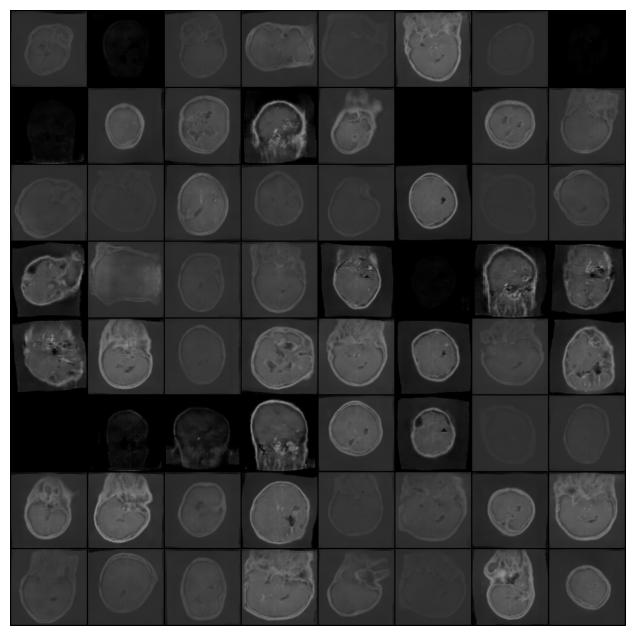

In [86]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from IPython.display import HTML
from PIL import Image
import os, glob

# 🔹 Doğru dizini buraya yaz:
FAKE_DIR = "/content/outputs/dcgan128_Glioma_ep150/fake"

img_list = sorted(glob.glob(os.path.join(FAKE_DIR, "grid_epoch_*.png")))
print(f"Toplam {len(img_list)} görsel bulundu.")

frames = []
for path in img_list:
    try:
        img = Image.open(path).convert("RGB")
        frames.append(np.asarray(img))
    except:
        pass

if len(frames) == 0:
    raise RuntimeError("Hiç görsel bulunamadı! FAKE_DIR yolunu kontrol et.")

# --- GIF oluştur ---
gif_path = os.path.join(FAKE_DIR, f"{CLASS_NAME}_training_progress.gif")
frames_pil = [Image.fromarray(f) for f in frames]
frames_pil[0].save(
    gif_path, save_all=True, append_images=frames_pil[1:], duration=800, loop=0
)
print("GIF kaydedildi:", gif_path)

# --- Notebook'ta oynat ---
fig = plt.figure(figsize=(8, 8))
plt.axis("off")
ims = [[plt.imshow(frames[i], animated=True)] for i in range(len(frames))]
ani = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)
HTML(ani.to_jshtml())


Toplam 5 görsel bulundu.
✅ GIF kaydedildi: /content/outputs/dcgan128_Glioma_ep150/fake/Glioma_training_progress.gif


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

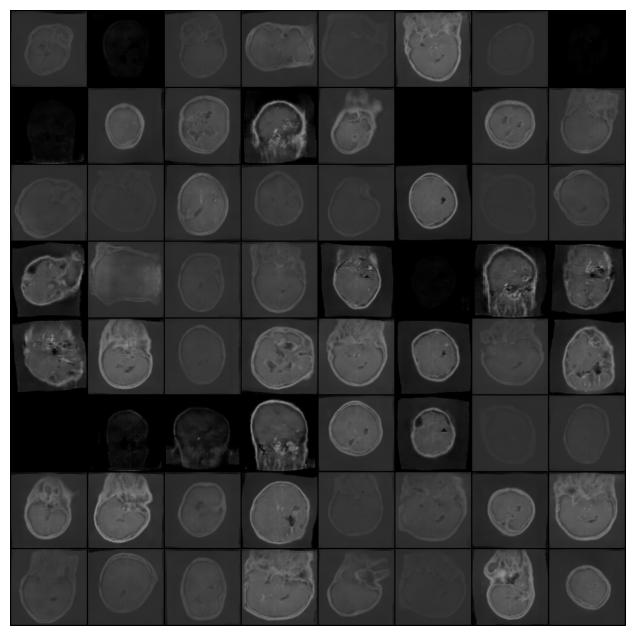

In [87]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from IPython.display import HTML
from PIL import Image
import os, glob
from google.colab import files

# 🔹 Burayı senin doğru klasörüne göre düzenle
FAKE_DIR = "/content/outputs/dcgan128_Glioma_ep150/fake"
CLASS_NAME = "Glioma"

# --- 1. Görselleri sırayla al ---
img_list = sorted(glob.glob(os.path.join(FAKE_DIR, "grid_epoch_*.png")))
print(f"Toplam {len(img_list)} görsel bulundu.")

frames = []
for path in img_list:
    try:
        img = Image.open(path).convert("RGB")
        frames.append(np.asarray(img))
    except Exception as e:
        print(f"❌ {path} yüklenemedi:", e)

if len(frames) == 0:
    raise RuntimeError("Hiç görsel bulunamadı! FAKE_DIR yolunu kontrol et.")

# --- 2. GIF oluştur ve kaydet ---
gif_path = os.path.join(FAKE_DIR, f"{CLASS_NAME}_training_progress.gif")
frames_pil = [Image.fromarray(f) for f in frames]
frames_pil[0].save(
    gif_path, save_all=True, append_images=frames_pil[1:], duration=800, loop=0
)
print("✅ GIF kaydedildi:", gif_path)

# --- 3. Notebook'ta görüntüle ---
fig = plt.figure(figsize=(8, 8))
plt.axis("off")
ims = [[plt.imshow(frames[i], animated=True)] for i in range(len(frames))]
ani = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)
HTML(ani.to_jshtml())

# --- 4. Bilgisayara indir ---
files.download(gif_path)


In [91]:
from torch_fidelity import calculate_metrics
import pandas as pd, os
from datetime import datetime

# 🔹 Tüm metrikleri hesapla
metrics_full = calculate_metrics(
    input1=REAL_DIR_RESIZED,
    input2=FAKE_DIR_RESIZED,
    cuda=torch.cuda.is_available(),
    fid=True, kid=True, inception_score=True, precision=True, recall=True,
    verbose=True,
    feature_extractor='inception-v3-compat',
    samples_find_deep=False,
    sample_resize=None,
    batch_size=64
)

# 🔹 Kaydetmek için tablo oluştur
row = {
    "class": CLASS_NAME,
    "n_real": len(os.listdir(REAL_DIR_RESIZED)),
    "n_fake": len(os.listdir(FAKE_DIR_RESIZED)),
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    **metrics_full
}

out = os.path.join(LOG_DIR, f"metrics_full_{CLASS_NAME}.csv")

# append biçiminde kaydet
df = pd.read_csv(out) if os.path.exists(out) else pd.DataFrame()
df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
df.to_csv(out, index=False)

print("✅ Kaydedildi:", out)
print("\n🔹 Hesaplanan metrikler:")
for k, v in metrics_full.items():
    print(f"{k:35s} {v}")


Creating feature extractor "inception-v3-compat" with features ['2048']
Extracting features from input1
Looking for samples non-recursivelty in "/content/train/Glioma_resized" with extensions png,jpg,jpeg
Found 4687 samples
Processing samples
Extracting features from input2
Looking for samples non-recursivelty in "/content/outputs/dcgan128_Glioma_ep150/fake/samples_resized" with extensions png,jpg,jpeg
Found 3000 samples
Processing samples
Frechet Inception Distance: 87.56590468194554
                                                                                

✅ Kaydedildi: /content/outputs/dcgan128_Glioma_ep150/logs/metrics_full_Glioma.csv

🔹 Hesaplanan metrikler:
frechet_inception_distance          87.56590468194554
kernel_inception_distance_mean      0.06180321216583252
kernel_inception_distance_std       0.0013899709051068793


Kernel Inception Distance: 0.06180321216583252 ± 0.0013899709051068793


In [89]:
pd.read_csv("/content/outputs/dcgan128_Glioma_ep150/logs/metrics_results_Glioma.csv")


,class,n_real,n_fake,timestamp,kernel_inception_distance_mean,kernel_inception_distance_std
0,Glioma,4687,3000,2025-10-26 16:40:22,0.061803,0.00139
